In [1]:
pip install langchain_openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 4.4 MB/s eta 0:00:00


In [2]:
!pip install -q bert-score
!pip install -q sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.1 MB/s eta 0:00:00


In [1]:
import pandas as pd

In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import os
import time
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers.string import StrOutputParser
#from langchain.schema import HumanMessage
from typing import Dict, List, Tuple
import asyncio
from tqdm.auto import tqdm
from langchain_core.messages import SystemMessage, HumanMessage


In [4]:
test_generation_examples = pd.read_csv('/content/test_generation_examples_1.5b_no_rl.csv')
test_generation_examples["client_id"] = (
        test_generation_examples["client_id"]
        .astype(str)
        .str.strip()
    )
t_full = pd.read_pickle("train_adapter_gpt.pkl")
test_multitask_df = pd.read_pickle('test_multitask_df.pkl')

In [6]:
os.environ['OPENAI_API_KEY'] = 'OPENAI_API_KEY'
os.environ['OPENAI_API_BASE'] = "OPENAI_API_BASE"
model_name = "gpt-4o-mini"

In [7]:
judge_base_llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    max_retries=5,
)

## All defs

In [8]:
TASK_CONFIGS = {
    "financial_profile": {
        "target_column": "financial_profile_target",
        "instruction": """
Describe the client's overall purchase transaction behavior.

Write a coherent behavioral profile connecting transaction activity,
spending intensity, purchase-size behavior, high-value purchases,
and category usage.

Mention the main category by total spending and recurring categories
by transaction frequency when this information is supported.
""".strip(),
    },

    "behavioral_summary": {
        "target_column": "behavioral_summary_target",
        "instruction": """
Summarize the client's purchase transaction behavior.

Write a concise natural-language summary of the most distinctive
behavioral patterns. Focus on meaningful relationships and contrasts
rather than listing every available attribute.
""".strip(),
    },

    "spending_style_analysis": {
        "target_column": "spending_style_analysis_target",
        "instruction": """
Analyze the client's spending style.

Explain how total and monthly spending relate to transaction frequency,
average purchase size, purchase-size variability, and high-value purchases.

Write a connected natural-language analysis rather than a list of labels.
""".strip(),
    },

    "category_mix_analysis": {
        "target_column": "category_mix_analysis_target",
        "instruction": """
Analyze the client's transaction category structure.

Describe the main category by total spending, the most frequent transaction
categories, their approximate shares, and whether the category pattern is
concentrated or diversified.

Clearly distinguish transaction frequency from total spending value.
""".strip(),
    },

    "analyst_observations": {
        "target_column": "analyst_observations_target",
        "instruction": """
Provide exactly three concise observations about the client's transaction behavior.

Each observation must connect at least two behavioral characteristics,
such as activity and spending, transaction frequency and purchase size,
or category frequency and spending concentration.

Do not introduce information that is not supported by the client representation.
""".strip(),
    },
}

In [9]:
evaluation_df = test_generation_examples.copy()
stats_df = t_full.copy()


# Приводим ключ объединения к одному типу
evaluation_df["client_id"] = (
    evaluation_df["client_id"]
    .astype(str)
    .str.strip()
)

stats_df["client_id"] = (
    stats_df["client_id"]
    .astype(str)
    .str.strip()
)


# В t_full должна быть одна строка на клиента
if stats_df["client_id"].duplicated().any():
    duplicated_ids = (
        stats_df.loc[
            stats_df["client_id"].duplicated(),
            "client_id",
        ]
        .unique()
        .tolist()
    )

    raise ValueError(
        "В t_full найдено несколько строк для одного client_id: "
        f"{duplicated_ids[:10]}"
    )


# Инструкция для каждого типа задания
task_to_instruction = {
    task_name: config["instruction"]
    for task_name, config in TASK_CONFIGS.items()
}

evaluation_df["instruction"] = (
    evaluation_df["task_type"]
    .map(task_to_instruction)
)

missing_tasks = evaluation_df.loc[
    evaluation_df["instruction"].isna(),
    "task_type",
].unique()

if len(missing_tasks) > 0:
    raise KeyError(
        "Для этих task_type нет инструкции в TASK_CONFIGS: "
        f"{missing_tasks.tolist()}"
    )


STAT_SECTIONS = {
    "Observation period": [
        ("num_transactions", "Number of transactions"),
        ("first_day", "First observed day"),
        ("last_day", "Last observed day"),
        ("period_days", "Observation period in days"),
        ("observed_months", "Observed months"),
    ],

    "Activity and transaction frequency": [
        ("active_days", "Active days"),
        ("active_day_rate", "Active day rate"),
        ("active_days_per_30d", "Active days per 30 days"),
        (
            "transactions_per_active_day",
            "Transactions per active day",
        ),
        (
            "transactions_per_30d",
            "Transactions per 30 days",
        ),
        (
            "transaction_frequency_level",
            "Transaction frequency level",
        ),
        ("active_days_level", "Active-days level"),
    ],

    "Spending behavior": [
        ("total_spent", "Total spending"),
        (
            "avg_monthly_spending",
            "Average monthly spending",
        ),
        (
            "avg_purchase_amount",
            "Average purchase amount",
        ),
        (
            "max_purchase_amount",
            "Maximum purchase amount",
        ),
        (
            "min_purchase_amount",
            "Minimum purchase amount",
        ),
        (
            "purchase_amount_std",
            "Purchase amount standard deviation",
        ),
        (
            "purchase_cv",
            "Purchase amount coefficient of variation",
        ),
        (
            "monthly_spending_level",
            "Monthly spending level",
        ),
        (
            "avg_purchase_level",
            "Average purchase level",
        ),
        (
            "total_spending_level",
            "Total spending level",
        ),
        (
            "purchase_size_variability",
            "Purchase size variability",
        ),
        (
            "high_value_purchase_pattern",
            "High-value purchase pattern",
        ),
    ],

    "Category diversity and concentration": [
        (
            "category_diversity",
            "Number of purchase categories",
        ),
        (
            "category_diversity_level",
            "Category diversity level",
        ),
        (
            "spending_concentration",
            "Spending concentration",
        ),
    ],

    "Top categories by spending": [
        (
            "top_1_category_by_spending",
            "Top spending category",
        ),
        (
            "top_1_category_spent",
            "Top category spending",
        ),
        (
            "top_1_category_share",
            "Top category spending share",
        ),
        (
            "top_2_category_by_spending",
            "Second spending category",
        ),
        (
            "top_2_category_spent",
            "Second category spending",
        ),
        (
            "top_2_category_share",
            "Second category spending share",
        ),
        (
            "top_3_category_by_spending",
            "Third spending category",
        ),
        (
            "top_3_category_spent",
            "Third category spending",
        ),
        (
            "top_3_category_share",
            "Third category spending share",
        ),
    ],

    "Top categories by frequency": [
        (
            "top_1_category_by_frequency",
            "Most frequent category",
        ),
        (
            "top_1_category_frequency_count",
            "Most frequent category transaction count",
        ),
        (
            "top_1_category_frequency_share",
            "Most frequent category share",
        ),
        (
            "top_2_category_by_frequency",
            "Second most frequent category",
        ),
        (
            "top_2_category_frequency_count",
            "Second category transaction count",
        ),
        (
            "top_2_category_frequency_share",
            "Second category frequency share",
        ),
        (
            "top_3_category_by_frequency",
            "Third most frequent category",
        ),
        (
            "top_3_category_frequency_count",
            "Third category transaction count",
        ),
        (
            "top_3_category_frequency_share",
            "Third category frequency share",
        ),
    ],
}


RATE_COLUMNS = {
    "active_day_rate",
    "top_1_category_share",
    "top_2_category_share",
    "top_3_category_share",
    "top_1_category_frequency_share",
    "top_2_category_frequency_share",
    "top_3_category_frequency_share",
}


def format_stat_value(column, value):
    if value is None or pd.isna(value):
        return None

    if isinstance(value, (float, np.floating)):
        if column in RATE_COLUMNS:
            return f"{float(value):.2%}"

        return f"{float(value):.4f}".rstrip("0").rstrip(".")

    if isinstance(value, (int, np.integer)):
        return str(int(value))

    return str(value).strip()


def build_full_statistics_description(row):
    sections = []

    for section_name, fields in STAT_SECTIONS.items():
        lines = []

        for column, label in fields:
            if column not in row.index:
                continue

            value = format_stat_value(
                column,
                row[column],
            )

            if value is not None and value != "":
                lines.append(f"- {label}: {value}")

        if lines:
            sections.append(
                section_name
                + ":\n"
                + "\n".join(lines)
            )

    return "\n\n".join(sections)


stats_df["source_description"] = stats_df.apply(
    build_full_statistics_description,
    axis=1,
)


# Сохраняем в объединённом датафрейме также исходные статистики
stat_columns = [
    column
    for fields in STAT_SECTIONS.values()
    for column, _ in fields
    if column in stats_df.columns
]

stats_for_merge = stats_df[
    [
        "client_id",
        *stat_columns,
        "source_description",
    ]
]


evaluation_df = evaluation_df.merge(
    stats_for_merge,
    on="client_id",
    how="left",
    validate="many_to_one",
)


missing_sources = evaluation_df[
    "source_description"
].isna().sum()

print(
    "Количество генераций:",
    len(evaluation_df),
)

print(
    "Не найдено исходных статистик:",
    missing_sources,
)

assert missing_sources == 0, (
    "Для части client_id из test_generation_examples "
    "не найдена строка в t_full."
)

display(
    evaluation_df[
        [
            "client_id",
            "task_type",
            "instruction",
            "target",
            "generated",
            "source_description",
        ]
    ].head()
)

Количество генераций: 1575
Не найдено исходных статистик: 0


,client_id,task_type,instruction,target,generated,source_description
0,39022,behavioral_summary,Summarize the client's purchase transaction be...,The user stands out for their low transaction ...,This individual demonstrates a high frequency ...,Observation period:\n- Number of transactions:...
1,24053,category_mix_analysis,Analyze the client's transaction category stru...,The main category for spending is chain superm...,The primary category for total spending is cha...,Observation period:\n- Number of transactions:...
2,37357,category_mix_analysis,Analyze the client's transaction category stru...,The main category for spending is chain superm...,The primary category for spending is chain sup...,Observation period:\n- Number of transactions:...
3,15510,analyst_observations,Provide exactly three concise observations abo...,1. The individual exhibits a moderate transact...,1. The individual maintains a middle level of ...,Observation period:\n- Number of transactions:...
4,15088,analyst_observations,Provide exactly three concise observations abo...,1. The individual engages in a high frequency ...,The individual shows a high variability in pur...,Observation period:\n- Number of transactions:...


In [10]:
# !pip install -q bert-score sentence-transformers

import asyncio
import inspect
import os
import re
import warnings

from pathlib import Path
from typing import Callable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from bert_score import score as bert_score
from pydantic import BaseModel, Field
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
from transformers import AutoModel


class GroundedOutputEvaluation(BaseModel):
    # Claims in the generated response
    supported_claims: int = Field(ge=0)
    contradicted_claims: int = Field(ge=0)
    unsupported_claims: int = Field(ge=0)

    # Facts from the teacher target
    valid_target_facts: int = Field(ge=0)
    covered_target_facts: int = Field(ge=0)
    invalid_target_facts: int = Field(ge=0)

    # New claims supported by source statistics
    novel_supported_claims: int = Field(ge=0)

    instruction_pass: bool

    unsupported_examples: list[str] = Field(
        default_factory=list
    )

    contradicted_examples: list[str] = Field(
        default_factory=list
    )

    novel_supported_examples: list[str] = Field(
        default_factory=list
    )

    missed_target_examples: list[str] = Field(
        default_factory=list
    )

    invalid_target_examples: list[str] = Field(
        default_factory=list
    )

    brief_reasoning: str = ""


class SingleModelNLPEvaluator:
    EVALUATION_VERSION = "grounded_target_v2_async"

    def __init__(
        self,
        dataset,
        judge_llm,
        source_col: str = "source_description",
        instruction_col: str = "instruction",
        target_col: str = "target",
        task_col: str = "task_type",
        prediction_col: str = "generated",
        generator_fn: Optional[Callable] = None,
        source_builder: Optional[Callable] = None,
        id_cols: Optional[list[str]] = None,
        use_semantic_similarity: bool = True,
        semantic_model_name: str = (
            "sentence-transformers/all-MiniLM-L6-v2"
        ),
        semantic_device: str = "cpu",
        semantic_batch_size: int = 32,
        use_bertscore: bool = True,
        bertscore_lang: str = "en",
        bertscore_model_type: Optional[str] = None,
        bertscore_device: str = "cpu",
        bertscore_batch_size: int = 16,
        rescale_bertscore: bool = True,
        bootstrap_iterations: int = 1000,
        max_retries: int = 4,
        seed: int = 42,
    ):
        self.dataset = dataset

        self.judge = judge_llm.with_structured_output(
            GroundedOutputEvaluation
        )

        self.source_col = source_col
        self.instruction_col = instruction_col
        self.target_col = target_col
        self.task_col = task_col
        self.prediction_col = prediction_col

        self.generator_fn = generator_fn
        self.source_builder = source_builder
        self.id_cols = id_cols or []

        self.use_semantic_similarity = (
            use_semantic_similarity
        )

        self.semantic_model_name = (
            semantic_model_name
        )

        self.semantic_device = semantic_device

        self.semantic_batch_size = (
            semantic_batch_size
        )

        self.semantic_model = None

        self.use_bertscore = use_bertscore
        self.bertscore_lang = bertscore_lang

        self.bertscore_model_type = (
            bertscore_model_type
        )

        self.bertscore_device = (
            bertscore_device
        )

        self.bertscore_batch_size = (
            bertscore_batch_size
        )

        self.rescale_bertscore = (
            rescale_bertscore
        )

        self.bootstrap_iterations = (
            bootstrap_iterations
        )

        self.max_retries = max_retries
        self.seed = seed

        self.rng = np.random.default_rng(
            seed
        )

        self.results_df = None
        self.summary_df = None
        self.task_summary_df = None

    def _dataset_length(self):
        return len(self.dataset)

    def _get_row(self, index):
        if isinstance(
            self.dataset,
            pd.DataFrame,
        ):
            return (
                self.dataset
                .iloc[index]
                .to_dict()
            )

        item = self.dataset[index]

        if isinstance(item, dict):
            return dict(item)

        if hasattr(item, "to_dict"):
            return item.to_dict()

        raise TypeError(
            "Элемент dataset должен быть словарём "
            "или поддерживать метод to_dict()."
        )

    @staticmethod
    def _to_text(value):
        if value is None:
            return ""

        if (
            isinstance(value, float)
            and np.isnan(value)
        ):
            return ""

        return str(value).strip()

    @staticmethod
    def _safe_scalar(value):
        if torch.is_tensor(value):
            if value.numel() == 1:
                return value.item()

            return str(
                value.detach().cpu().tolist()
            )

        if isinstance(value, np.generic):
            return value.item()

        return value

    def _get_source_description(
        self,
        row,
    ):
        if self.source_builder is not None:
            source = self.source_builder(
                row
            )
        else:
            source = row.get(
                self.source_col
            )

        source = self._to_text(
            source
        )

        if not source:
            raise ValueError(
                "Не найдено полное описание статистик. "
                f"Добавь колонку {self.source_col!r} "
                "или передай source_builder."
            )

        return source

    @staticmethod
    def _extract_prediction_text(
        output,
    ):
        if isinstance(output, str):
            return output.strip()

        if isinstance(output, tuple):
            for value in reversed(output):
                if isinstance(value, str):
                    return value.strip()

        if isinstance(output, dict):
            for key in [
                "generated",
                "generated_text",
                "prediction",
                "text",
                "output",
            ]:
                if key in output:
                    value = output[key]

                    if value is None:
                        return ""

                    return str(value).strip()

        raise TypeError(
            "generator_fn должна вернуть строку, "
            "tuple с текстом или dict с текстом."
        )

    async def _get_prediction_async(
        self,
        row,
    ):
        prediction = self._to_text(
            row.get(
                self.prediction_col
            )
        )

        if prediction:
            return prediction

        if self.generator_fn is None:
            raise ValueError(
                f"В колонке {self.prediction_col!r} "
                "нет генерации и generator_fn не передана."
            )

        output = self.generator_fn(
            row
        )

        if inspect.isawaitable(output):
            output = await output

        return self._extract_prediction_text(
            output
        )

    @staticmethod
    def _word_tokens(text):
        return re.findall(
            r"\b[\w'-]+\b",
            text.lower(),
            flags=re.UNICODE,
        )

    @staticmethod
    def _sentences(text):
        sentences = re.split(
            r"(?<=[.!?])\s+|\n+",
            text.strip(),
        )

        return [
            sentence.strip()
            for sentence in sentences
            if sentence.strip()
        ]

    def _text_diagnostics(
        self,
        text,
    ):
        tokens = self._word_tokens(
            text
        )

        sentences = self._sentences(
            text
        )

        word_count = len(tokens)
        sentence_count = len(sentences)

        if len(tokens) >= 2:
            bigrams = list(
                zip(
                    tokens[:-1],
                    tokens[1:],
                )
            )

            distinct_2 = (
                len(set(bigrams))
                / len(bigrams)
            )
        else:
            distinct_2 = 1.0

        normalized_sentences = [
            re.sub(
                r"\W+",
                " ",
                sentence.lower(),
            ).strip()
            for sentence in sentences
        ]

        if normalized_sentences:
            duplicate_sentence_rate = (
                1
                - len(
                    set(
                        normalized_sentences
                    )
                )
                / len(
                    normalized_sentences
                )
            )
        else:
            duplicate_sentence_rate = 0.0

        return {
            "word_count": word_count,
            "sentence_count": sentence_count,
            "distinct_2": distinct_2,
            "repetition_rate": (
                1.0 - distinct_2
            ),
            "duplicate_sentence_rate": (
                duplicate_sentence_rate
            ),
        }

    @staticmethod
    def _build_judge_prompt(
        source_description,
        target,
        instruction,
        generated_text,
    ):
        return f"""
You are evaluating a generated description of a client's purchase
transaction behavior.

There are two different reference sources.

FULL CLIENT STATISTICS:
This is the factual ground truth. Use it to determine whether generated
claims are supported, contradicted or unsupported.

TEACHER TARGET:
This is an incomplete silver reference. Use it only to identify the
expected facts for target recall. Do not treat the teacher target as
factual ground truth when it conflicts with the full statistics.

FULL CLIENT STATISTICS

{source_description}

TEACHER TARGET

{target}

TASK INSTRUCTION

{instruction}

GENERATED RESPONSE

{generated_text}

Follow these evaluation rules.

1. GENERATED CLAIMS

Split the generated response into atomic factual claims.

Classify each generated claim into exactly one category:

- supported:
  directly supported by the full client statistics;

- contradicted:
  conflicts with the full client statistics;

- unsupported:
  neither supported nor contradicted by the full client statistics.

General plausibility is not evidence.

Unsupported inferences about income, wealth, age, gender, occupation,
personality, health, family status, creditworthiness, motivations or
personal circumstances must be classified as unsupported.

2. TARGET RECALL

Split the teacher target into atomic facts.

A target fact is valid only when it is supported by the full client
statistics.

Count:

- valid_target_facts:
  target facts supported by the full statistics;

- covered_target_facts:
  valid target facts expressed in the generated response, allowing
  paraphrases;

- invalid_target_facts:
  target facts not supported by the full statistics.

Do not penalize the generated response for failing to reproduce invalid
teacher-target facts.

3. NOVEL SUPPORTED CLAIMS

A novel supported claim:

- appears in the generated response;
- is supported by the full client statistics;
- is not expressed or semantically implied by the teacher target.

Count such claims in novel_supported_claims.

4. INSTRUCTION FOLLOWING

instruction_pass is true only when the generated response materially
answers the requested task and satisfies explicit structural
requirements.

Do not count purely stylistic phrases as factual claims.

Return concise examples for unsupported, contradicted, novel supported,
missed target and invalid target facts.
""".strip()

    async def _judge_prediction_async(
        self,
        source_description,
        target,
        instruction,
        generated_text,
        semaphore,
        request_timeout=180,
    ):
        prompt = self._build_judge_prompt(
            source_description=(
                source_description
            ),
            target=target,
            instruction=instruction,
            generated_text=generated_text,
        )

        last_error = None

        for attempt in range(
            self.max_retries
        ):
            try:
                async with semaphore:
                    request = (
                        self.judge.ainvoke(
                            prompt
                        )
                    )

                    if request_timeout is None:
                        evaluation = (
                            await request
                        )
                    else:
                        evaluation = (
                            await asyncio.wait_for(
                                request,
                                timeout=(
                                    request_timeout
                                ),
                            )
                        )

                if isinstance(
                    evaluation,
                    dict,
                ):
                    if hasattr(
                        GroundedOutputEvaluation,
                        "model_validate",
                    ):
                        evaluation = (
                            GroundedOutputEvaluation
                            .model_validate(
                                evaluation
                            )
                        )
                    else:
                        evaluation = (
                            GroundedOutputEvaluation
                            .parse_obj(
                                evaluation
                            )
                        )

                return evaluation

            except Exception as error:
                last_error = error

                if (
                    attempt + 1
                    < self.max_retries
                ):
                    delay = min(
                        2 ** attempt,
                        30,
                    )

                    print(
                        "Ошибка LLM API, "
                        f"попытка {attempt + 1}/"
                        f"{self.max_retries}: "
                        f"{error}. "
                        f"Повтор через {delay} сек."
                    )

                    await asyncio.sleep(
                        delay
                    )

        raise RuntimeError(
            "Не удалось получить оценку "
            "от LLM-judge после "
            f"{self.max_retries} попыток."
        ) from last_error

    @staticmethod
    def _calculate_claim_metrics(
        evaluation,
    ):
        supported = int(
            evaluation.supported_claims
        )

        contradicted = int(
            evaluation.contradicted_claims
        )

        unsupported = int(
            evaluation.unsupported_claims
        )

        generated_claims = (
            supported
            + contradicted
            + unsupported
        )

        valid_target_facts = int(
            evaluation.valid_target_facts
        )

        covered_target_facts = min(
            int(
                evaluation
                .covered_target_facts
            ),
            valid_target_facts,
        )

        novel_supported_claims = min(
            int(
                evaluation
                .novel_supported_claims
            ),
            supported,
        )

        if generated_claims > 0:
            source_factual_precision = (
                supported
                / generated_claims
            )

            novel_supported_claim_rate = (
                novel_supported_claims
                / generated_claims
            )

            unsupported_claim_ratio = (
                unsupported
                / generated_claims
            )

            contradiction_claim_ratio = (
                contradicted
                / generated_claims
            )

        else:
            source_factual_precision = 0.0
            novel_supported_claim_rate = 0.0
            unsupported_claim_ratio = 0.0
            contradiction_claim_ratio = 0.0

        if valid_target_facts > 0:
            target_recall = (
                covered_target_facts
                / valid_target_facts
            )
        else:
            target_recall = np.nan

        return {
            "generated_claims": (
                generated_claims
            ),
            "supported_claims": supported,
            "contradicted_claims": (
                contradicted
            ),
            "unsupported_claims": (
                unsupported
            ),
            "valid_target_facts": (
                valid_target_facts
            ),
            "covered_target_facts": (
                covered_target_facts
            ),
            "invalid_target_facts": int(
                evaluation
                .invalid_target_facts
            ),
            "novel_supported_claims": (
                novel_supported_claims
            ),
            "source_factual_precision": (
                source_factual_precision
            ),
            "target_recall": target_recall,
            "novel_supported_claim_rate": (
                novel_supported_claim_rate
            ),
            "unsupported_claim_ratio": (
                unsupported_claim_ratio
            ),
            "contradiction_claim_ratio": (
                contradiction_claim_ratio
            ),
            "contradiction_flag": int(
                contradicted > 0
            ),
            "unsupported_flag": int(
                unsupported > 0
            ),
        }

    def _build_result(
        self,
        sample_id,
        row,
        source_description,
        target,
        instruction,
        task_name,
        generated_text,
        evaluation,
    ):
        result = {
            "evaluation_version": (
                self.EVALUATION_VERSION
            ),
            "sample_id": sample_id,
            "task_name": task_name,
            "instruction": instruction,
            "target": target,
            "source_description": (
                source_description
            ),
            "generated_text": (
                generated_text
            ),

            **self._calculate_claim_metrics(
                evaluation
            ),

            **self._text_diagnostics(
                generated_text
            ),

            "instruction_pass": int(
                evaluation.instruction_pass
            ),

            "unsupported_examples": (
                " | ".join(
                    evaluation
                    .unsupported_examples
                )
            ),

            "contradicted_examples": (
                " | ".join(
                    evaluation
                    .contradicted_examples
                )
            ),

            "novel_supported_examples": (
                " | ".join(
                    evaluation
                    .novel_supported_examples
                )
            ),

            "missed_target_examples": (
                " | ".join(
                    evaluation
                    .missed_target_examples
                )
            ),

            "invalid_target_examples": (
                " | ".join(
                    evaluation
                    .invalid_target_examples
                )
            ),

            "judge_reasoning": (
                evaluation.brief_reasoning
            ),
        }

        for column in self.id_cols:
            if column in row:
                result[column] = (
                    self._safe_scalar(
                        row[column]
                    )
                )

        return result

    async def _evaluate_single_async(
        self,
        sample_id,
        row,
        semaphore,
        request_timeout=180,
    ):
        source_description = (
            self._get_source_description(
                row
            )
        )

        target = self._to_text(
            row.get(
                self.target_col
            )
        )

        instruction = self._to_text(
            row.get(
                self.instruction_col
            )
        )

        task_name = (
            self._to_text(
                row.get(
                    self.task_col
                )
            )
            or "unknown"
        )

        generated_text = (
            await self
            ._get_prediction_async(
                row
            )
        )

        evaluation = (
            await self
            ._judge_prediction_async(
                source_description=(
                    source_description
                ),
                target=target,
                instruction=instruction,
                generated_text=(
                    generated_text
                ),
                semaphore=semaphore,
                request_timeout=(
                    request_timeout
                ),
            )
        )

        return self._build_result(
            sample_id=sample_id,
            row=row,
            source_description=(
                source_description
            ),
            target=target,
            instruction=instruction,
            task_name=task_name,
            generated_text=generated_text,
            evaluation=evaluation,
        )

    def _get_semantic_model(self):
        if self.semantic_model is None:
            model_kwargs = {
                "attn_implementation": (
                    "eager"
                ),
                "torch_dtype": (
                    torch.float32
                ),
            }

            try:
                self.semantic_model = (
                    SentenceTransformer(
                        self.semantic_model_name,
                        device=(
                            self.semantic_device
                        ),
                        model_kwargs=(
                            model_kwargs
                        ),
                    )
                )

            except TypeError:
                self.semantic_model = (
                    SentenceTransformer(
                        self.semantic_model_name,
                        device=(
                            self.semantic_device
                        ),
                    )
                )

        return self.semantic_model

    def _add_semantic_similarity(
        self,
        dataframe,
    ):
        dataframe = dataframe.copy()

        dataframe[
            "semantic_similarity"
        ] = np.nan

        if not self.use_semantic_similarity:
            return dataframe

        valid_mask = (
            dataframe[
                "generated_text"
            ]
            .fillna("")
            .str.strip()
            .ne("")
            &
            dataframe[
                "target"
            ]
            .fillna("")
            .str.strip()
            .ne("")
        )

        valid_indices = (
            dataframe.index[
                valid_mask
            ].tolist()
        )

        if not valid_indices:
            return dataframe

        generated_texts = (
            dataframe.loc[
                valid_indices,
                "generated_text",
            ].tolist()
        )

        targets = dataframe.loc[
            valid_indices,
            "target",
        ].tolist()

        model = (
            self._get_semantic_model()
        )

        generated_embeddings = (
            model.encode(
                generated_texts,
                batch_size=(
                    self.semantic_batch_size
                ),
                convert_to_numpy=True,
                normalize_embeddings=True,
                show_progress_bar=True,
            )
        )

        target_embeddings = (
            model.encode(
                targets,
                batch_size=(
                    self.semantic_batch_size
                ),
                convert_to_numpy=True,
                normalize_embeddings=True,
                show_progress_bar=True,
            )
        )

        similarities = np.sum(
            generated_embeddings
            * target_embeddings,
            axis=1,
        )

        dataframe.loc[
            valid_indices,
            "semantic_similarity",
        ] = similarities

        return dataframe

    def _add_bertscore(
        self,
        dataframe,
    ):
        dataframe = dataframe.copy()

        dataframe[
            "bertscore_precision"
        ] = np.nan

        dataframe[
            "bertscore_recall"
        ] = np.nan

        dataframe[
            "bertscore_f1"
        ] = np.nan

        if not self.use_bertscore:
            return dataframe

        valid_mask = (
            dataframe[
                "generated_text"
            ]
            .fillna("")
            .str.strip()
            .ne("")
            &
            dataframe[
                "target"
            ]
            .fillna("")
            .str.strip()
            .ne("")
        )

        valid_indices = (
            dataframe.index[
                valid_mask
            ].tolist()
        )

        if not valid_indices:
            return dataframe

        candidates = dataframe.loc[
            valid_indices,
            "generated_text",
        ].tolist()

        references = dataframe.loc[
            valid_indices,
            "target",
        ].tolist()

        kwargs = {
            "cands": candidates,
            "refs": references,
            "device": (
                self.bertscore_device
            ),
            "batch_size": (
                self.bertscore_batch_size
            ),
            "verbose": False,
            "rescale_with_baseline": (
                self.rescale_bertscore
            ),
        }

        if (
            self.bertscore_model_type
            is not None
        ):
            kwargs["model_type"] = (
                self.bertscore_model_type
            )
        else:
            kwargs["lang"] = (
                self.bertscore_lang
            )

        original_from_pretrained = (
            AutoModel
            .from_pretrained
            .__func__
        )

        def eager_from_pretrained(
            cls,
            *args,
            **model_kwargs,
        ):
            model_kwargs[
                "attn_implementation"
            ] = "eager"

            return original_from_pretrained(
                cls,
                *args,
                **model_kwargs,
            )

        AutoModel.from_pretrained = (
            classmethod(
                eager_from_pretrained
            )
        )

        try:
            precision, recall, f1 = (
                bert_score(
                    **kwargs
                )
            )

        except Exception as error:
            warnings.warn(
                "Не удалось рассчитать "
                f"BERTScore: {error}"
            )

            return dataframe

        finally:
            AutoModel.from_pretrained = (
                classmethod(
                    original_from_pretrained
                )
            )

        dataframe.loc[
            valid_indices,
            "bertscore_precision",
        ] = (
            precision
            .detach()
            .cpu()
            .numpy()
        )

        dataframe.loc[
            valid_indices,
            "bertscore_recall",
        ] = (
            recall
            .detach()
            .cpu()
            .numpy()
        )

        dataframe.loc[
            valid_indices,
            "bertscore_f1",
        ] = (
            f1
            .detach()
            .cpu()
            .numpy()
        )

        return dataframe

    @staticmethod
    def _prepare_results_dataframe(
        existing_df,
        new_results,
    ):
        results_df = pd.concat(
            [
                existing_df,
                pd.DataFrame(
                    new_results
                ),
            ],
            ignore_index=True,
        )

        if results_df.empty:
            return results_df

        return (
            results_df
            .drop_duplicates(
                subset=["sample_id"],
                keep="last",
            )
            .sort_values(
                "sample_id"
            )
            .reset_index(
                drop=True
            )
        )

    async def _save_checkpoint_async(
        self,
        existing_df,
        new_results,
        checkpoint_path,
    ):
        partial_df = (
            self._prepare_results_dataframe(
                existing_df=existing_df,
                new_results=new_results,
            )
        )

        if partial_df.empty:
            return

        checkpoint_path = Path(
            checkpoint_path
        )

        checkpoint_path.parent.mkdir(
            parents=True,
            exist_ok=True,
        )

        await asyncio.to_thread(
            partial_df.to_csv,
            checkpoint_path,
            index=False,
        )

    async def evaluate_async(
        self,
        max_samples=None,
        checkpoint_path=None,
        save_every=10,
        random_sample=False,
        force_recompute=False,
        max_concurrency=8,
        request_timeout=180,
    ):
        if max_concurrency < 1:
            raise ValueError(
                "max_concurrency должен "
                "быть не меньше 1."
            )

        if save_every < 1:
            raise ValueError(
                "save_every должен быть "
                "не меньше 1."
            )

        if not hasattr(
            self.judge,
            "ainvoke",
        ):
            raise TypeError(
                "Текущий judge_llm "
                "не поддерживает ainvoke()."
            )

        indices = np.arange(
            self._dataset_length()
        )

        if (
            max_samples is not None
            and max_samples < len(indices)
        ):
            if random_sample:
                indices = self.rng.choice(
                    indices,
                    size=max_samples,
                    replace=False,
                )
            else:
                indices = indices[
                    :max_samples
                ]

        indices = [
            int(index)
            for index in indices
        ]

        existing_df = pd.DataFrame()
        completed_ids = set()

        if (
            checkpoint_path is not None
            and os.path.exists(
                checkpoint_path
            )
            and not force_recompute
        ):
            loaded_df = pd.read_csv(
                checkpoint_path
            )

            correct_version = (
                "evaluation_version"
                in loaded_df.columns
                and loaded_df[
                    "evaluation_version"
                ]
                .eq(
                    self.EVALUATION_VERSION
                )
                .all()
            )

            if correct_version:
                existing_df = loaded_df

                completed_ids = set(
                    existing_df[
                        "sample_id"
                    ].astype(int)
                )

                print(
                    "Уже оценено примеров: "
                    f"{len(completed_ids)}"
                )

            else:
                print(
                    "Старый checkpoint имеет "
                    "другую схему и будет "
                    "проигнорирован."
                )

        remaining_indices = [
            index
            for index in indices
            if index not in completed_ids
        ]

        if not remaining_indices:
            results_df = (
                existing_df.copy()
            )

        else:
            semaphore = (
                asyncio.Semaphore(
                    max_concurrency
                )
            )

            async def evaluate_index(
                sample_id,
            ):
                row = self._get_row(
                    sample_id
                )

                return await (
                    self
                    ._evaluate_single_async(
                        sample_id=(
                            sample_id
                        ),
                        row=row,
                        semaphore=(
                            semaphore
                        ),
                        request_timeout=(
                            request_timeout
                        ),
                    )
                )

            new_results = []

            index_iterator = iter(
                remaining_indices
            )

            pending_tasks = set()

            initial_task_count = min(
                max_concurrency,
                len(
                    remaining_indices
                ),
            )

            for _ in range(
                initial_task_count
            ):
                sample_id = next(
                    index_iterator
                )

                pending_tasks.add(
                    asyncio.create_task(
                        evaluate_index(
                            sample_id
                        )
                    )
                )

            progress_bar = tqdm(
                total=len(
                    remaining_indices
                ),
                desc=(
                    "Evaluating asynchronously"
                ),
            )

            try:
                while pending_tasks:
                    (
                        done_tasks,
                        pending_tasks,
                    ) = await asyncio.wait(
                        pending_tasks,
                        return_when=(
                            asyncio
                            .FIRST_COMPLETED
                        ),
                    )

                    for completed_task in (
                        done_tasks
                    ):
                        result = (
                            completed_task
                            .result()
                        )

                        new_results.append(
                            result
                        )

                        progress_bar.update(
                            1
                        )

                        if (
                            checkpoint_path
                            is not None
                            and len(
                                new_results
                            )
                            % save_every
                            == 0
                        ):
                            await (
                                self
                                ._save_checkpoint_async(
                                    existing_df=(
                                        existing_df
                                    ),
                                    new_results=(
                                        new_results
                                    ),
                                    checkpoint_path=(
                                        checkpoint_path
                                    ),
                                )
                            )

                        try:
                            next_sample_id = (
                                next(
                                    index_iterator
                                )
                            )

                        except StopIteration:
                            next_sample_id = (
                                None
                            )

                        if (
                            next_sample_id
                            is not None
                        ):
                            pending_tasks.add(
                                asyncio
                                .create_task(
                                    evaluate_index(
                                        next_sample_id
                                    )
                                )
                            )

            except Exception:
                for task in pending_tasks:
                    task.cancel()

                if pending_tasks:
                    await asyncio.gather(
                        *pending_tasks,
                        return_exceptions=True,
                    )

                if (
                    checkpoint_path
                    is not None
                    and new_results
                ):
                    await (
                        self
                        ._save_checkpoint_async(
                            existing_df=(
                                existing_df
                            ),
                            new_results=(
                                new_results
                            ),
                            checkpoint_path=(
                                checkpoint_path
                            ),
                        )
                    )

                raise

            finally:
                progress_bar.close()

            results_df = (
                self
                ._prepare_results_dataframe(
                    existing_df=(
                        existing_df
                    ),
                    new_results=(
                        new_results
                    ),
                )
            )

        if results_df.empty:
            raise RuntimeError(
                "Нет результатов для оценки."
            )

        print(
            "LLM-оценка завершена. "
            "Рассчитывается semantic similarity."
        )

        results_df = (
            self
            ._add_semantic_similarity(
                results_df
            )
        )

        print(
            "Рассчитывается BERTScore."
        )

        results_df = (
            self._add_bertscore(
                results_df
            )
        )

        if checkpoint_path is not None:
            checkpoint_path = Path(
                checkpoint_path
            )

            checkpoint_path.parent.mkdir(
                parents=True,
                exist_ok=True,
            )

            results_df.to_csv(
                checkpoint_path,
                index=False,
            )

        self.results_df = results_df

        return results_df

    def _bootstrap_mean_ci(
        self,
        values,
    ):
        values = (
            pd.Series(values)
            .dropna()
            .to_numpy(
                dtype=float
            )
        )

        if len(values) == 0:
            return np.nan, np.nan

        if len(values) == 1:
            return (
                values[0],
                values[0],
            )

        bootstrap_means = np.empty(
            self.bootstrap_iterations
        )

        for index in range(
            self.bootstrap_iterations
        ):
            sample = self.rng.choice(
                values,
                size=len(values),
                replace=True,
            )

            bootstrap_means[index] = (
                sample.mean()
            )

        ci_low, ci_high = np.quantile(
            bootstrap_means,
            [0.025, 0.975],
        )

        return ci_low, ci_high

    def build_summary(
        self,
        results_df=None,
    ):
        if results_df is None:
            results_df = (
                self.results_df
            )

        if results_df is None:
            raise RuntimeError(
                "Сначала вызови "
                "evaluate_async()."
            )

        metrics = {
            "Source factual precision": (
                "source_factual_precision"
            ),

            "Target recall": (
                "target_recall"
            ),

            "Novel supported claim rate": (
                "novel_supported_claim_rate"
            ),

            "Semantic similarity": (
                "semantic_similarity"
            ),

            "BERTScore F1": (
                "bertscore_f1"
            ),

            "Instruction pass rate": (
                "instruction_pass"
            ),

            "Contradiction rate": (
                "contradiction_flag"
            ),

            "Unsupported claim ratio": (
                "unsupported_claim_ratio"
            ),

            "Contradicted claim ratio": (
                "contradiction_claim_ratio"
            ),

            "Repetition rate": (
                "repetition_rate"
            ),

            "Average word count": (
                "word_count"
            ),

            "Invalid target facts per response": (
                "invalid_target_facts"
            ),
        }

        rows = []

        for metric_name, column in (
            metrics.items()
        ):
            values = results_df[
                column
            ]

            ci_low, ci_high = (
                self._bootstrap_mean_ci(
                    values
                )
            )

            rows.append(
                {
                    "metric": metric_name,
                    "value": values.mean(),
                    "ci_low": ci_low,
                    "ci_high": ci_high,
                    "n": (
                        values
                        .notna()
                        .sum()
                    ),
                }
            )

        self.summary_df = pd.DataFrame(
            rows
        )

        return self.summary_df

    def build_task_summary(
        self,
        results_df=None,
    ):
        if results_df is None:
            results_df = (
                self.results_df
            )

        if results_df is None:
            raise RuntimeError(
                "Сначала вызови "
                "evaluate_async()."
            )

        self.task_summary_df = (
            results_df
            .groupby(
                "task_name",
                dropna=False,
            )
            .agg(
                n=(
                    "sample_id",
                    "count",
                ),

                source_factual_precision=(
                    "source_factual_precision",
                    "mean",
                ),

                target_recall=(
                    "target_recall",
                    "mean",
                ),

                novel_supported_claim_rate=(
                    "novel_supported_claim_rate",
                    "mean",
                ),

                semantic_similarity=(
                    "semantic_similarity",
                    "mean",
                ),

                bertscore_f1=(
                    "bertscore_f1",
                    "mean",
                ),

                instruction_pass_rate=(
                    "instruction_pass",
                    "mean",
                ),

                contradiction_rate=(
                    "contradiction_flag",
                    "mean",
                ),

                unsupported_claim_ratio=(
                    "unsupported_claim_ratio",
                    "mean",
                ),

                contradiction_claim_ratio=(
                    "contradiction_claim_ratio",
                    "mean",
                ),

                repetition_rate=(
                    "repetition_rate",
                    "mean",
                ),

                average_word_count=(
                    "word_count",
                    "mean",
                ),

                invalid_target_facts_per_response=(
                    "invalid_target_facts",
                    "mean",
                ),
            )
            .reset_index()
        )

        return self.task_summary_df

    def plot_overall_quality(
        self,
        show=True,
    ):
        if self.summary_df is None:
            self.build_summary()

        values = dict(
            zip(
                self.summary_df[
                    "metric"
                ],
                self.summary_df[
                    "value"
                ],
            )
        )

        plot_data = pd.Series(
            {
                "Source factual precision": (
                    values[
                        "Source factual precision"
                    ]
                ),

                "Target recall": (
                    values[
                        "Target recall"
                    ]
                ),

                "Novel supported claims": (
                    values[
                        "Novel supported claim rate"
                    ]
                ),

                "Semantic similarity": (
                    values[
                        "Semantic similarity"
                    ]
                ),

                "BERTScore F1": (
                    values[
                        "BERTScore F1"
                    ]
                ),

                "Instruction pass": (
                    values[
                        "Instruction pass rate"
                    ]
                ),
            }
        ).dropna()

        figure, axis = plt.subplots(
            figsize=(11, 5)
        )

        plot_data.plot(
            kind="bar",
            ax=axis,
        )

        axis.set_ylim(
            0,
            1,
        )

        axis.set_ylabel(
            "Score"
        )

        axis.set_title(
            "Overall model quality"
        )

        axis.grid(
            axis="y",
            alpha=0.3,
        )

        plt.xticks(
            rotation=35,
            ha="right",
        )

        plt.tight_layout()

        if show:
            plt.show()

        return figure

    def plot_overall_errors(
        self,
        show=True,
    ):
        if self.summary_df is None:
            self.build_summary()

        values = dict(
            zip(
                self.summary_df[
                    "metric"
                ],
                self.summary_df[
                    "value"
                ],
            )
        )

        plot_data = pd.Series(
            {
                "Contradiction rate": (
                    values[
                        "Contradiction rate"
                    ]
                ),

                "Unsupported claim ratio": (
                    values[
                        "Unsupported claim ratio"
                    ]
                ),

                "Contradicted claim ratio": (
                    values[
                        "Contradicted claim ratio"
                    ]
                ),

                "Repetition rate": (
                    values[
                        "Repetition rate"
                    ]
                ),
            }
        ).dropna()

        figure, axis = plt.subplots(
            figsize=(9, 5)
        )

        plot_data.plot(
            kind="bar",
            ax=axis,
        )

        axis.set_ylim(
            0,
            1,
        )

        axis.set_ylabel(
            "Rate"
        )

        axis.set_title(
            "Model error rates"
        )

        axis.grid(
            axis="y",
            alpha=0.3,
        )

        plt.xticks(
            rotation=30,
            ha="right",
        )

        plt.tight_layout()

        if show:
            plt.show()

        return figure

    def plot_quality_by_task(
        self,
        show=True,
    ):
        if self.task_summary_df is None:
            self.build_task_summary()

        columns = [
            "source_factual_precision",
            "target_recall",
            "novel_supported_claim_rate",
            "semantic_similarity",
            "bertscore_f1",
            "instruction_pass_rate",
        ]

        plot_df = (
            self.task_summary_df
            .set_index(
                "task_name"
            )[columns]
            .rename(
                columns={
                    "source_factual_precision": (
                        "Source precision"
                    ),

                    "target_recall": (
                        "Target recall"
                    ),

                    "novel_supported_claim_rate": (
                        "Novel supported"
                    ),

                    "semantic_similarity": (
                        "Semantic similarity"
                    ),

                    "bertscore_f1": (
                        "BERTScore F1"
                    ),

                    "instruction_pass_rate": (
                        "Instruction pass"
                    ),
                }
            )
        )

        figure, axis = plt.subplots(
            figsize=(14, 6)
        )

        plot_df.plot(
            kind="bar",
            ax=axis,
        )

        axis.set_ylim(
            0,
            1,
        )

        axis.set_xlabel(
            "Task"
        )

        axis.set_ylabel(
            "Score"
        )

        axis.set_title(
            "Model quality by task"
        )

        axis.grid(
            axis="y",
            alpha=0.3,
        )

        plt.xticks(
            rotation=35,
            ha="right",
        )

        plt.tight_layout()

        if show:
            plt.show()

        return figure

    def plot_errors_by_task(
        self,
        show=True,
    ):
        if self.task_summary_df is None:
            self.build_task_summary()

        columns = [
            "contradiction_rate",
            "unsupported_claim_ratio",
            "contradiction_claim_ratio",
            "repetition_rate",
        ]

        plot_df = (
            self.task_summary_df
            .set_index(
                "task_name"
            )[columns]
            .rename(
                columns={
                    "contradiction_rate": (
                        "Contradiction rate"
                    ),

                    "unsupported_claim_ratio": (
                        "Unsupported ratio"
                    ),

                    "contradiction_claim_ratio": (
                        "Contradicted ratio"
                    ),

                    "repetition_rate": (
                        "Repetition rate"
                    ),
                }
            )
        )

        figure, axis = plt.subplots(
            figsize=(12, 6)
        )

        plot_df.plot(
            kind="bar",
            ax=axis,
        )

        axis.set_ylim(
            0,
            1,
        )

        axis.set_xlabel(
            "Task"
        )

        axis.set_ylabel(
            "Rate"
        )

        axis.set_title(
            "Model errors by task"
        )

        axis.grid(
            axis="y",
            alpha=0.3,
        )

        plt.xticks(
            rotation=35,
            ha="right",
        )

        plt.tight_layout()

        if show:
            plt.show()

        return figure

    def save_outputs(
        self,
        output_dir=(
            "evaluation_results"
        ),
        save_plots=True,
    ):
        output_dir = Path(
            output_dir
        )

        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        if self.results_df is None:
            raise RuntimeError(
                "Сначала вызови "
                "evaluate_async()."
            )

        if self.summary_df is None:
            self.build_summary()

        if self.task_summary_df is None:
            self.build_task_summary()

        self.results_df.to_csv(
            output_dir
            / "detailed_results.csv",
            index=False,
        )

        self.summary_df.to_csv(
            output_dir
            / "summary_metrics.csv",
            index=False,
        )

        self.task_summary_df.to_csv(
            output_dir
            / "metrics_by_task.csv",
            index=False,
        )

        if save_plots:
            figures = {
                "overall_quality": (
                    self
                    .plot_overall_quality(
                        show=False
                    )
                ),

                "overall_errors": (
                    self
                    .plot_overall_errors(
                        show=False
                    )
                ),

                "quality_by_task": (
                    self
                    .plot_quality_by_task(
                        show=False
                    )
                ),

                "errors_by_task": (
                    self
                    .plot_errors_by_task(
                        show=False
                    )
                ),
            }

            for name, figure in (
                figures.items()
            ):
                figure.savefig(
                    output_dir
                    / f"{name}.png",
                    dpi=200,
                    bbox_inches="tight",
                )

                plt.close(
                    figure
                )

    async def run_all_async(
        self,
        max_samples=None,
        checkpoint_path=None,
        output_dir=(
            "evaluation_results"
        ),
        save_every=10,
        random_sample=False,
        force_recompute=False,
        make_plots=True,
        max_concurrency=8,
        request_timeout=180,
    ):
        results_df = (
            await self.evaluate_async(
                max_samples=max_samples,
                checkpoint_path=(
                    checkpoint_path
                ),
                save_every=save_every,
                random_sample=(
                    random_sample
                ),
                force_recompute=(
                    force_recompute
                ),
                max_concurrency=(
                    max_concurrency
                ),
                request_timeout=(
                    request_timeout
                ),
            )
        )

        summary_df = (
            self.build_summary(
                results_df
            )
        )

        task_summary_df = (
            self.build_task_summary(
                results_df
            )
        )

        self.save_outputs(
            output_dir=output_dir,
            save_plots=make_plots,
        )

        if make_plots:
            self.plot_overall_quality()
            self.plot_overall_errors()
            self.plot_quality_by_task()
            self.plot_errors_by_task()

        return (
            results_df,
            summary_df,
            task_summary_df,
        )

In [11]:
from transformers import AutoModel


def _add_bertscore_eager(self, dataframe):
    dataframe = dataframe.copy()

    dataframe["bertscore_precision"] = np.nan
    dataframe["bertscore_recall"] = np.nan
    dataframe["bertscore_f1"] = np.nan

    valid_mask = (
        dataframe["generated_text"]
        .fillna("")
        .str.strip()
        .ne("")
        &
        dataframe["target"]
        .fillna("")
        .str.strip()
        .ne("")
    )

    valid_indices = dataframe.index[
        valid_mask
    ].tolist()

    if not valid_indices:
        return dataframe

    candidates = dataframe.loc[
        valid_indices,
        "generated_text",
    ].tolist()

    references = dataframe.loc[
        valid_indices,
        "target",
    ].tolist()

    kwargs = {
        "cands": candidates,
        "refs": references,
        "device": self.bertscore_device,
        "batch_size": self.bertscore_batch_size,
        "verbose": False,
        "rescale_with_baseline": self.rescale_bertscore,
    }

    if self.bertscore_model_type is not None:
        kwargs["model_type"] = self.bertscore_model_type
    else:
        kwargs["lang"] = self.bertscore_lang

    original_from_pretrained = (
        AutoModel.from_pretrained.__func__
    )

    def eager_from_pretrained(
        cls,
        *args,
        **model_kwargs,
    ):
        model_kwargs["attn_implementation"] = "eager"

        return original_from_pretrained(
            cls,
            *args,
            **model_kwargs,
        )

    AutoModel.from_pretrained = classmethod(
        eager_from_pretrained
    )

    try:
        precision, recall, f1 = bert_score(
            **kwargs
        )

    finally:
        AutoModel.from_pretrained = classmethod(
            original_from_pretrained
        )

    dataframe.loc[
        valid_indices,
        "bertscore_precision",
    ] = precision.detach().cpu().numpy()

    dataframe.loc[
        valid_indices,
        "bertscore_recall",
    ] = recall.detach().cpu().numpy()

    dataframe.loc[
        valid_indices,
        "bertscore_f1",
    ] = f1.detach().cpu().numpy()

    return dataframe


SingleModelNLPEvaluator._add_bertscore = (
    _add_bertscore_eager
)

In [12]:
def _get_semantic_model_eager(self):
    if self.semantic_model is None:
        self.semantic_model = SentenceTransformer(
            self.semantic_model_name,
            device=self.semantic_device,
            model_kwargs={
                "attn_implementation": "eager",
            },
        )

    return self.semantic_model


SingleModelNLPEvaluator._get_semantic_model = (
    _get_semantic_model_eager
)

In [13]:
def build_source_description(row):
    possible_fields = [
        "behavioral_summary",
        "category_mix_analysis",
        "analyst_observations",
        "financial_profile",
        "spending_style_analysis",
    ]

    for field in possible_fields:
        if field in row:
            value = row[field]

            if value is not None and str(value).strip():
                return str(value).strip()

    if "target" in row:
        return str(row["target"]).strip()

    raise KeyError(
        "В элементе датасета нет исходного описания клиента. "
        "Добавь поле source_description или client_facts."
    )

## Run

Evaluating asynchronously:   0%|          | 0/1575 [00:00<?, ?it/s]

LLM-оценка завершена. Рассчитывается semantic similarity.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


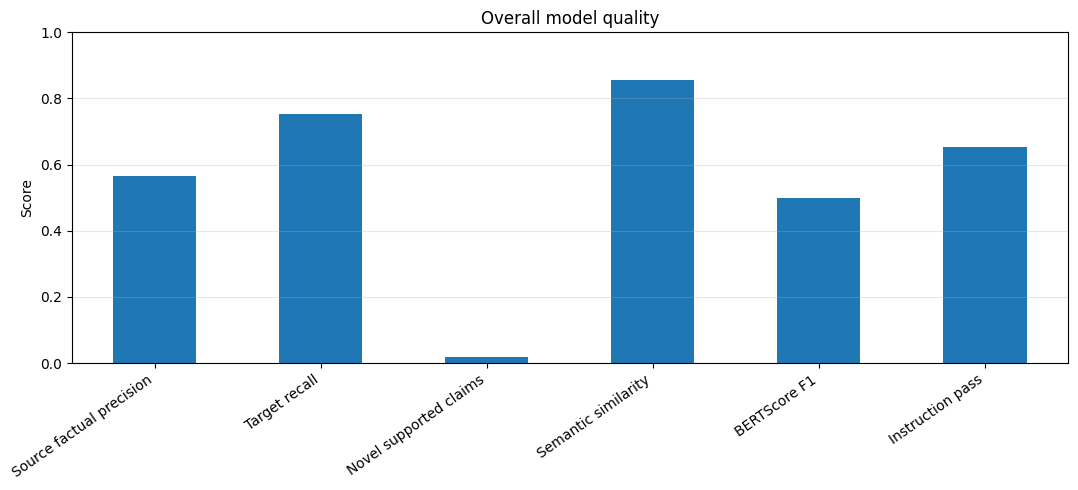

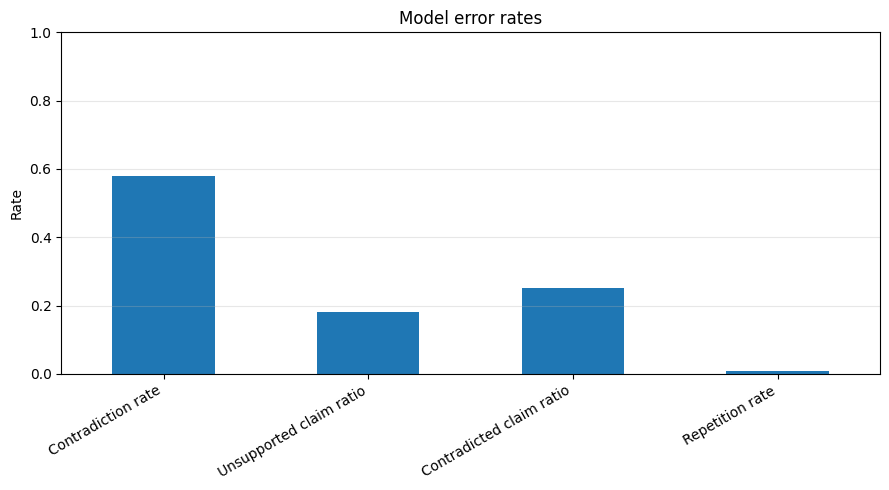

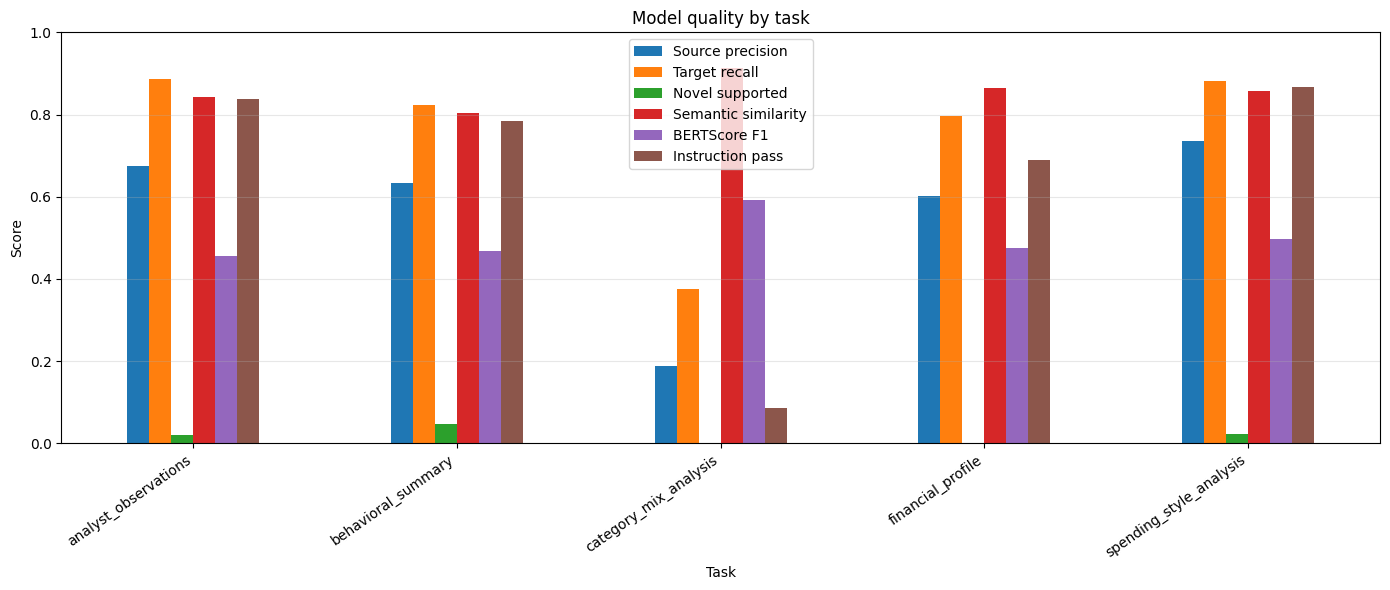

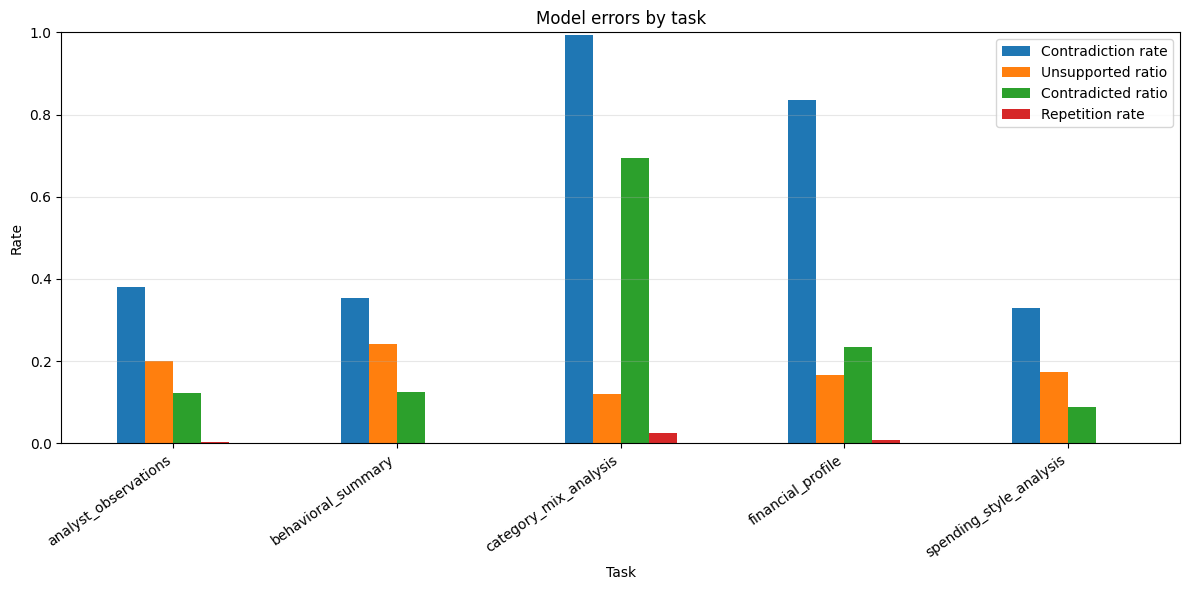

In [14]:
evaluation_df = test_generation_examples.copy()


evaluation_df["instruction"] = evaluation_df["task_type"].map(
    lambda task: TASK_CONFIGS[task]["instruction"]
)
source_df = test_multitask_df.copy()
source_df["source_description"] = source_df.apply(
    build_source_description,
    axis=1,
)

source_df = (
    source_df[
        [
            "client_id",
            "task_type",
            "source_description",
        ]
    ]
    .drop_duplicates(
        subset=[
            "client_id",
            "task_type",
        ]
    )
)

evaluation_df = evaluation_df.merge(
    source_df,
    on=[
        "client_id",
        "task_type",
    ],
    how="left",
)

evaluation_dataset = evaluation_df.to_dict(
    orient="records"
)


evaluator = SingleModelNLPEvaluator(
    dataset=evaluation_dataset,
    judge_llm=judge_base_llm,
    source_col="source_description",
    instruction_col="instruction",
    target_col="target",
    task_col="task_type",
    prediction_col="generated",
    id_cols=["client_id"],
    semantic_device="cpu",
    bertscore_device="cuda",
    bertscore_batch_size=32,
)

results_df, summary_df, task_summary_df = (
    await evaluator.run_all_async(
        max_samples=None,
        checkpoint_path=(
            "evaluation_results/"
            "async_checkpoint.csv"
        ),
        output_dir=(
            "evaluation_results/final"
        ),
        save_every=10,
        random_sample=False,
        force_recompute=False,
        make_plots=True,
        max_concurrency=8,
        request_timeout=180,
    )
)

In [15]:
summary_df

,metric,value,ci_low,ci_high,n
0,Source factual precision,0.566792,0.551212,0.582213,1575
1,Target recall,0.752095,0.735776,0.767792,1575
2,Novel supported claim rate,0.018376,0.015406,0.021789,1575
3,Semantic similarity,0.856263,0.853203,0.859121,1575
4,BERTScore F1,0.498093,0.494320,0.501677,1575
5,Instruction pass rate,0.652698,0.629206,0.674921,1575
6,Contradiction rate,0.578413,0.554286,0.602540,1575
7,Unsupported claim ratio,0.180407,0.172564,0.188128,1575
8,Contradicted claim ratio,0.252801,0.237929,0.266275,1575
9,Repetition rate,0.007449,0.006584,0.008365,1575


In [16]:
task_summary_df

,task_name,n,source_factual_precision,target_recall,novel_supported_claim_rate,semantic_similarity,bertscore_f1,instruction_pass_rate,contradiction_rate,unsupported_claim_ratio,contradiction_claim_ratio,repetition_rate,average_word_count,invalid_target_facts_per_response
0,analyst_observations,315,0.675661,0.885556,0.019259,0.841898,0.456917,0.838095,0.380952,0.201164,0.123175,0.002644,67.009524,0.000000
1,behavioral_summary,315,0.632698,0.821958,0.047831,0.804759,0.469046,0.784127,0.352381,0.242389,0.124913,0.000153,41.361905,0.000000
2,category_mix_analysis,315,0.187483,0.376138,0.000635,0.913751,0.592739,0.085714,0.993651,0.119116,0.693401,0.025346,63.339683,0.009524
3,financial_profile,315,0.601358,0.795450,0.000983,0.863341,0.474787,0.688889,0.834921,0.165446,0.233196,0.007245,77.339683,0.015873
4,spending_style_analysis,315,0.736757,0.881376,0.023175,0.857569,0.496979,0.866667,0.330159,0.173923,0.089320,0.001855,61.577778,0.000000


## save



In [17]:
summary_df.to_csv('summary_df_no_rl.csv', index=False)
task_summary_df.to_csv('task_summary_df_no_rl.csv', index=False)
results_df.to_csv('results_df_no_rl.csv', index=False)